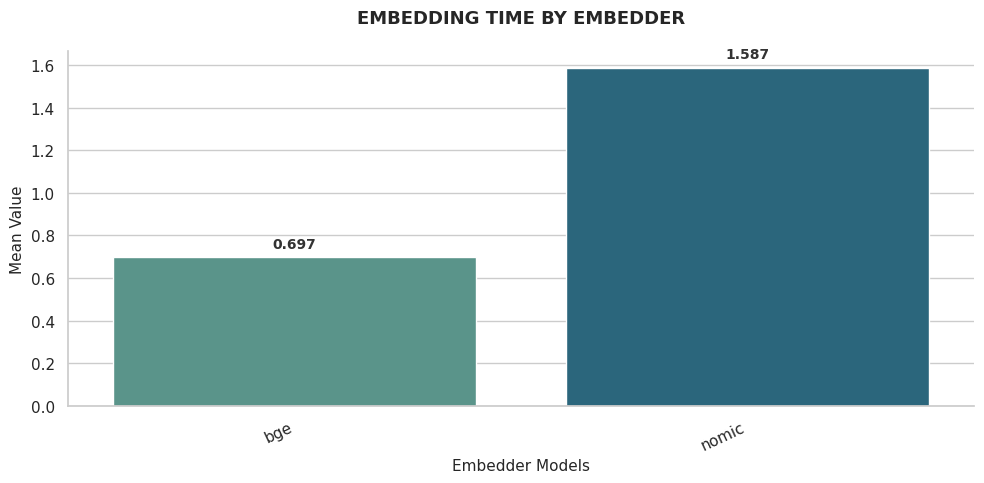

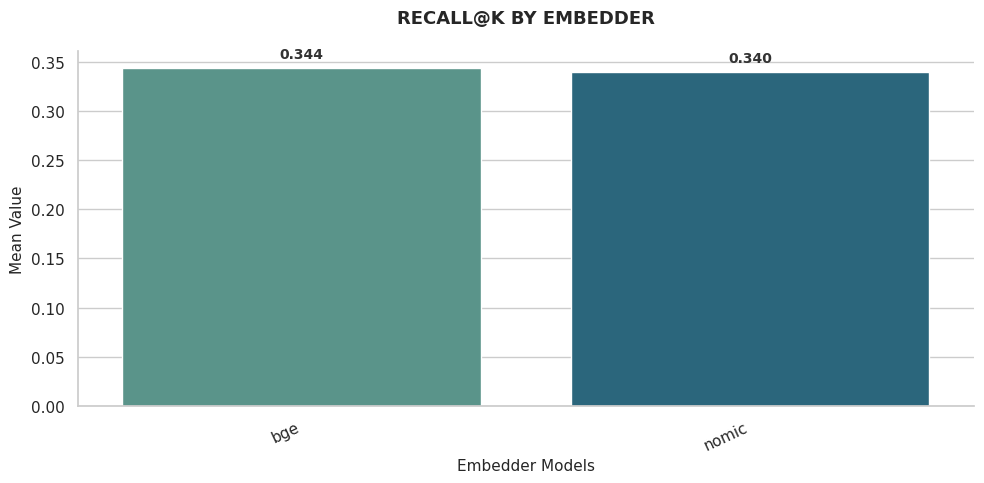

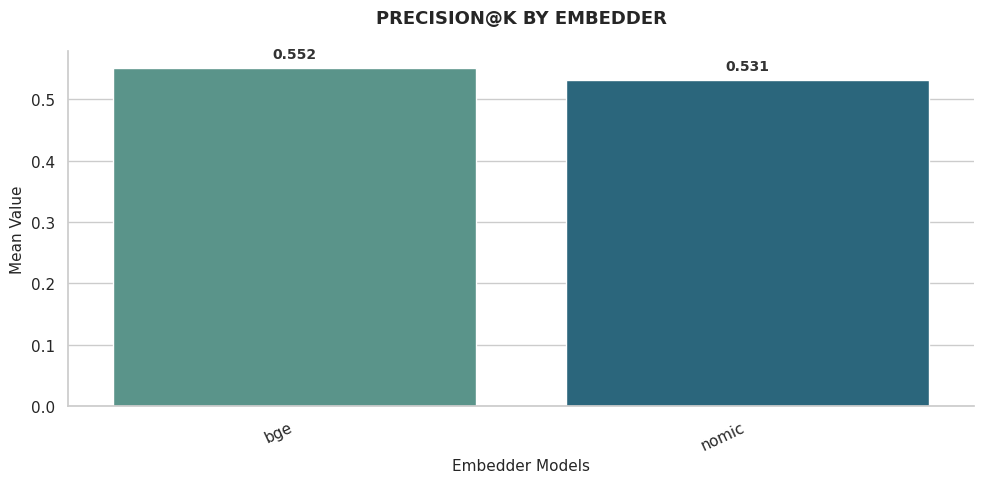

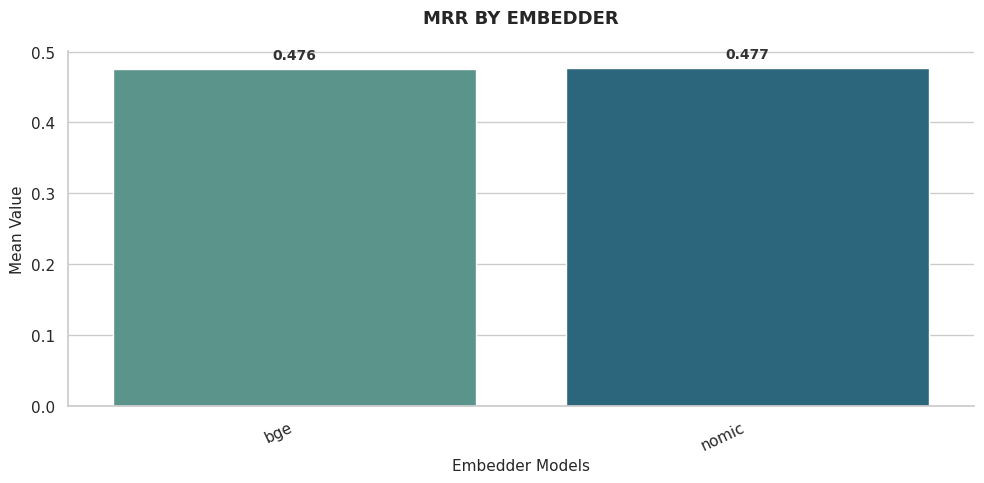

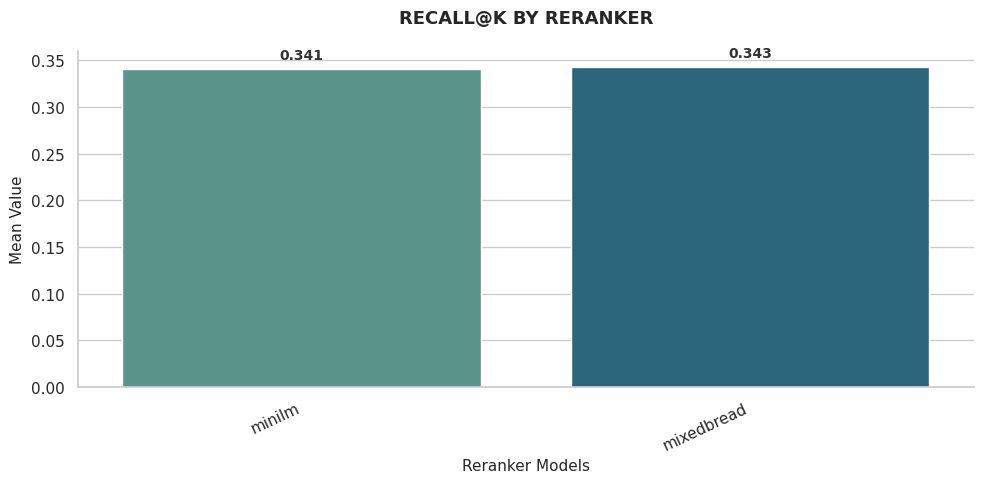

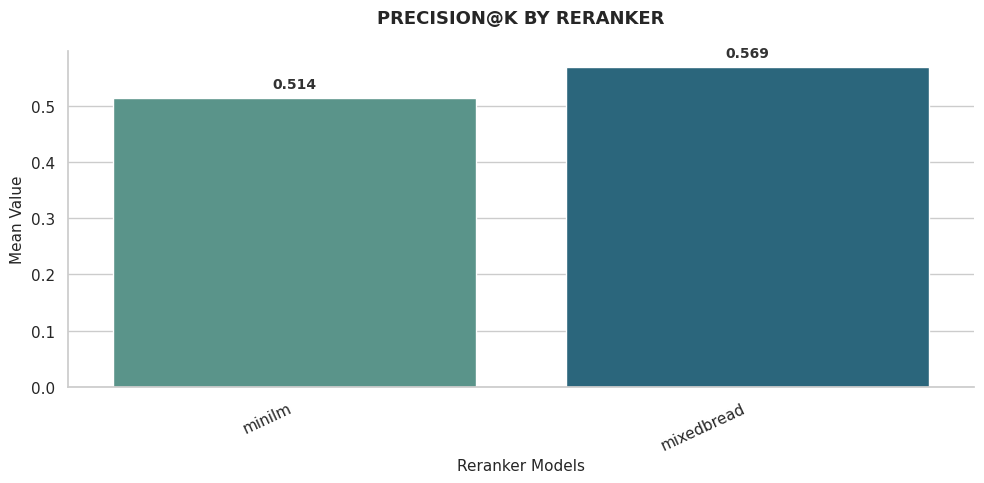

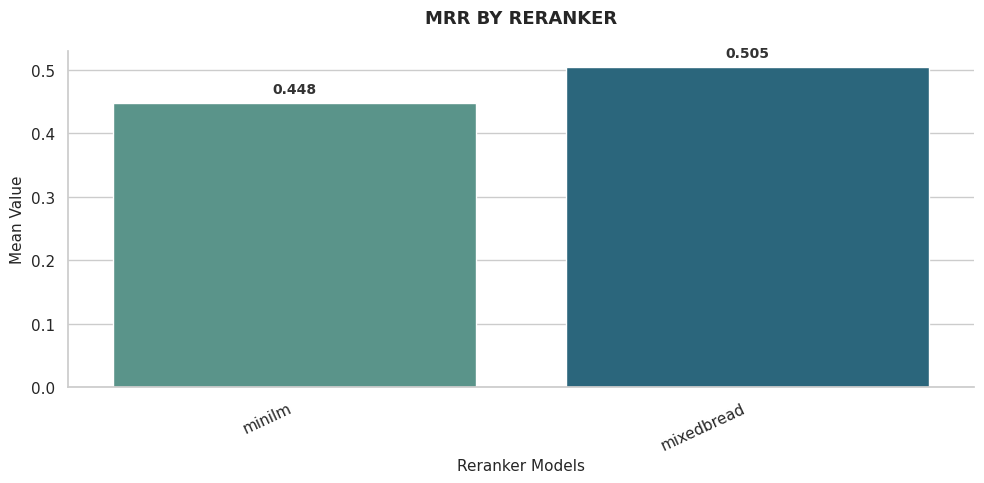

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. إعداد التنسيق والألوان
sns.set_theme(style="whitegrid")
UNIQUE_PALETTE = "crest"

# 2. تحميل البيانات
file_path = "rag_results.csv"
df = pd.read_csv(file_path)

# 3. تحديد المقاييس والمجموعات (Embedder و Reranker)
groups = [
    {"metrics": ["embedding_time", "recall@k", "precision@k", "mrr"], "model_col": "embedder"},
    {"metrics": ["recall@k", "precision@k", "mrr"], "model_col": "reranker"}
]

# 4. حلقة لرسم وعرض كل Metric
for group in groups:
    model_col = group["model_col"]

    for metric in group["metrics"]:
        # إنشاء الشكل (Figure)
        fig, ax = plt.subplots(figsize=(10, 5))

        # تصفية البيانات للمقياس الحالي
        filtered_df = df[df["metric"] == metric]

        # حساب المتوسط لكل موديل
        grouped = filtered_df.groupby(model_col)["value"].mean().reset_index()

        # رسم الـ Bar plot
        sns.barplot(
            data=grouped,
            x=model_col,
            y="value",
            palette=UNIQUE_PALETTE,
            hue=model_col,
            ax=ax
        )

        # إزالة الـ Legend لأنه غير ضروري هنا
        if ax.get_legend() is not None:
            ax.get_legend().remove()

        # تحسين العناوين والمسميات
        clean_title = metric.replace('_', ' ').upper()
        ax.set_title(f"{clean_title} BY {model_col.upper()}", fontsize=13, fontweight='bold', pad=20)
        ax.set_xlabel(f"{model_col.capitalize()} Models", fontsize=11)
        ax.set_ylabel("Mean Value", fontsize=11)

        plt.xticks(rotation=25, ha='right')
        sns.despine()

        # إضافة الأرقام فوق الأعمدة
        for p in ax.patches:
            height = p.get_height()
            if not pd.isna(height):
                ax.annotate(f'{height:.3f}',
                            (p.get_x() + p.get_width() / 2., height),
                            ha='center', va='center',
                            xytext=(0, 10),
                            textcoords='offset points',
                            fontsize=10, fontweight='bold', color='#333')

        plt.tight_layout()

        # --- التعديل هنا للعرض المباشر ---
        plt.show()